## Step 1 : Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Step 2 : Define Dataset Path

In [2]:
train_path = r"D:\MyLearning\Python_WS\LMS_ProITBridge\Jupyter_Files\DL\CNN_Image_Clasification\train_data"
val_path   = r"D:\MyLearning\Python_WS\LMS_ProITBridge\Jupyter_Files\DL\CNN_Image_Clasification\val_data"
test_path  = r"D:\MyLearning\Python_WS\LMS_ProITBridge\Jupyter_Files\DL\CNN_Image_Clasification\test_data"

## Step 3 : Define Parameters | Step 4 : Data Preprocessing

In [3]:
IMAGE_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 25

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

## Step 5 : Load Dataset

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 20 images belonging to 4 classes.
Found 8 images belonging to 4 classes.
Found 12 images belonging to 4 classes.


In [5]:
print(train_generator.class_indices)

{'Ajith': 0, 'Kamal': 1, 'Rajini': 2, 'Vijay': 3}


## Step 7 : Display Images

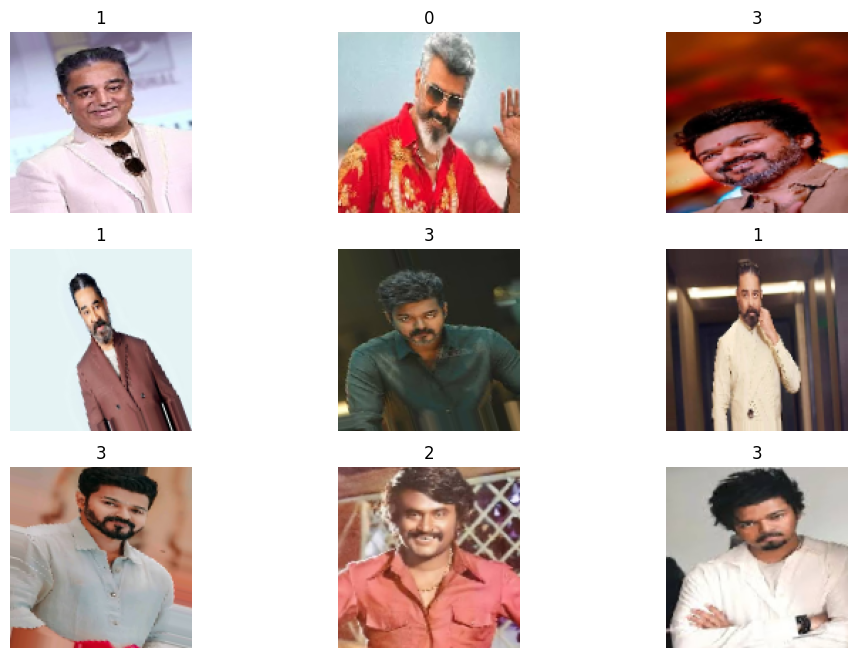

In [6]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(np.argmax(labels[i]))

    plt.axis("off")

plt.show()

## Step 8 : Build CNN Model

In [ ]:
model = Sequential()

# Layer 1
model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2

model.add(Conv2D(64,(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3

model.add(Conv2D(128,(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 4

model.add(Conv2D(256,(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten

model.add(Flatten())

# Dense Layer

model.add(Dense(256,activation='relu'))

model.add(Dropout(0.5))

# Output Layer

model.add(Dense(4,activation='softmax'))

## Step 9 : View Model

In [ ]:
model.summary()

## Step 10 : Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 11 : Callbacks

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

## Step 12 : Train Model

In [ ]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[early_stop,checkpoint]

)

## Step 13 : Plot Accuracy

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

## Step 14 : Plot Loss

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

## Step 15 : Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

## Step 16 : Predictions

In [ ]:
prediction = model.predict(test_generator)

predicted_class = np.argmax(prediction,axis=1)

true_class = test_generator.classes

## Step 17 : Classification Report

In [ ]:
print(classification_report(
    true_class,
    predicted_class,
    target_names=list(test_generator.class_indices.keys())
))

## Step 18 : Confusion Matrix

In [ ]:
cm = confusion_matrix(true_class,predicted_class)

print(cm)

## Step 19 : Save Model

In [ ]:
model.save("FaceClassifier.keras")

## Step 21 : Predict a Single Image

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image
img_path = r"D:\TestImages\sample.jpg"

img = image.load_img(
    img_path,
    target_size=(128, 128)
)

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get predicted class index
predicted_index = np.argmax(prediction)

# Convert class indices to class names
class_names = {v: k for k, v in train_generator.class_indices.items()}

# Get predicted person name
predicted_person = class_names[predicted_index]

# Prediction confidence
confidence = np.max(prediction) * 100

print(f"Predicted Person : {predicted_person}")
print(f"Confidence       : {confidence:.2f}%")

CNN Summary

In [ ]:
| Layer      | Output Filters | Purpose                                    |
| ---------- | -------------: | ------------------------------------------ |
| Input      |  128 × 128 × 3 | RGB Image                                  |
| Conv2D     |             32 | Learn low-level features (edges, textures) |
| MaxPooling |              - | Reduce spatial dimensions                  |
| Conv2D     |             64 | Learn more complex patterns                |
| MaxPooling |              - | Downsampling                               |
| Conv2D     |            128 | Higher-level feature extraction            |
| MaxPooling |              - | Downsampling                               |
| Conv2D     |            256 | Deep feature extraction                    |
| MaxPooling |              - | Downsampling                               |
| Flatten    |              - | Convert feature maps to a vector           |
| Dense      |            256 | Fully connected learning                   |
| Dropout    |            0.5 | Reduce overfitting                         |
| Dense      |              4 | Four-class classification (Softmax)        |
